<a href="https://colab.research.google.com/github/sugamthapa47/SugamThapa_INFO4670_Spring2026/blob/main/INFO%204670%20Assignment%204%20.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 12: Assignment 4 — SMS Spam Detection

**Goal:** Apply the six-step classification workflow to a real dataset.
Predict whether an SMS message is spam or legitimate (ham) using text-based features.

---

## I. Assignment Objective

By completing this assignment, you will:
- Follow a complete classification pipeline on real-world data
- Engineer binary features from raw text
- Train and evaluate a Decision Tree and a Naive Bayes classifier
- Interpret a confusion matrix and choose the right evaluation metric
- Analyze model performance and reflect on possible improvements

---

## II. Dataset

**Source:** UCI SMS Spam Collection (5,572 real SMS messages, no login required)

| Column | Description | Example |
|---|---|---|
| `label` | Class label | `spam` or `ham` |
| `message` | Raw SMS text | "WINNER!! You have been selected..." |
| `spam` | Encoded label (1 = spam, 0 = ham) | 1 |

Load it with one line — no file upload needed:
```python
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/00228/smsspamcollection.zip'
```

---

## III. Grading Rubric (Total = 100 points)

| Section | What is graded | Points |
|---|---|---|
| Step 1 — Problem definition | Q1a + Q1b + Q1c (written) | 10 |
| Step 2 — Explore the data | Code runs correctly (2B, 2C, 2D) | 15 |
| Step 3 — Feature engineering | Code (3B, 3C) + Q3a + Q3b + Q3c (written) | 20 |
| Step 4 — Split the data | Code (4A) + Q4a + Q4b (written) | 10 |
| Step 5 — Train models | Code: 5A + 5B + 5C + 5D (5 pts each) | 20 |
| Step 6 — Code (6A + 6B + 6C) | Each code block runs correctly (4 pts each) | 12 |
| Step 6 — Written (Q6a–Q6d) | Q6a (3) + Q6b (3) + Q6c (4) + Q6d (3) | 13 |
| **Total** | | **100** |

---

## IV. Steps to Complete

Follow the steps below in order.
Each code cell starts with `# Write your code here` — replace it with your implementation.


---
### Setup — Run this cell first (provided)

In [1]:
# This cell is provided — run it before starting
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.naive_bayes import BernoulliNB
from sklearn.metrics import (
    confusion_matrix, accuracy_score, precision_score,
    recall_score, f1_score, ConfusionMatrixDisplay
)
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
import warnings
warnings.filterwarnings('ignore')
np.random.seed(42)
print('Setup complete!')


Setup complete!


---
## Step 1 — Define the Problem

Before writing any code, answer the questions below.
Your answers here should guide every metric decision you make in Step 6.

**Context:**
A mobile carrier wants an automated classifier to flag spam SMS messages
before they reach users. The two possible errors are:

| Error | What happens |
|---|---|
| False Positive | A real (ham) message gets blocked |
| False Negative | A spam message reaches the user |

### Q1 — Problem Definition *(10 points)*

**Q1a.** Which error is more costly in a real spam filter — False Positive or False Negative?
Give one concrete real-world consequence for each.

*Your answer:*
> **False Positive is more costly.** A False Positive means a legitimate (ham) message is incorrectly
> blocked and never delivered to the user. A concrete real-world consequence: a user misses their
> bank's one-time password during an urgent transaction, or a doctor's appointment reminder is silently
> dropped — causing them to miss a critical medical visit. A False Negative means spam slips through to
> the user. The consequence is mild inconvenience: the user sees an unwanted message, recognises it as
> spam, and deletes it — no lasting harm done. The asymmetry is clear: blocking an important message
> causes immediate, tangible damage; receiving spam does not.

**Q1b.** Based on Q1a, which metric should be your primary evaluation target?
Choose one: **Precision**, **Recall**, or **F1-Score**. Explain why.

*Your answer:*
> **Precision** should be the primary evaluation target. Since False Positives are more costly
> (blocking legitimate messages erodes user trust and causes real harm), we want to ensure that when
> the model predicts "spam," it is almost always correct. Precision = TP / (TP + FP) directly captures
> this: it is the fraction of spam-predicted messages that truly are spam. A high Precision means very
> few legitimate messages are incorrectly blocked. Optimising for Recall alone would increase the number
> of spam messages caught but at the cost of more false alarms on legitimate messages. F1 balances both,
> but because we explicitly prioritise minimising FP, Precision is the most appropriate primary metric.

**Q1c.** The spam rate in this dataset is about 13%.
What accuracy would a dummy model that always predicts "ham" achieve?
Is that number still misleading? Why?

*Your answer:*
> A dummy model that always predicts "ham" would achieve **~86.6% accuracy** — simply because 86.6% of
> all messages are legitimate ham. This number is deeply misleading. Despite the high score, the model
> catches **zero spam**: its Recall on the spam class is 0% and its F1-Score is 0%. A spam filter that
> never blocks any spam is completely useless, yet accuracy scores it at 86.6%. This is the
> "Accuracy Trap": on imbalanced datasets, accuracy rewards predicting the majority class and reveals
> nothing about the model's ability to detect the minority class (spam). Class-specific metrics such as
> Precision, Recall, and F1 are far more informative for this problem.

---
## Step 2 — Load and Explore the Data

### Step 2A — Load the dataset



In [2]:
import urllib.request, zipfile, io

url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/00228/smsspamcollection.zip'
print('Downloading UCI SMS Spam Collection...')
with urllib.request.urlopen(url) as r:
    zf = zipfile.ZipFile(io.BytesIO(r.read()))
    with zf.open('SMSSpamCollection') as f:
        raw = pd.read_csv(f, sep='\t', header=None, names=['label', 'message'])

raw['spam'] = (raw['label'] == 'spam').astype(int)
print(f'Loaded: {len(raw)} messages')
raw.head(6)


Loaded: 5572 messages


,label,message,spam
0,ham,"Go until jurong point, crazy.. Available only ...",0
1,ham,Ok lar... Joking wif u oni...,0
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,1
3,ham,U dun say so early hor... U c already then say...,0
4,ham,"Nah I don't think he goes to usf, he lives aro...",0
5,spam,FreeMsg Hey there darling it's been 3 week's n...,1


### Step 2B — Class distribution

**Hint:** Print the count and percentage of spam and ham messages.
Plot a bar chart with spam count in red and ham count in blue.
Also run a dummy model (predict all ham) and print its Accuracy, Recall, and F1.
This proves the Accuracy Trap from Lecture 8.


Class distribution:
  Ham  (0): 4,825  (86.6%)
  Spam (1): 747  (13.4%)

Dummy model (always predict ham):
  Accuracy  = 86.6%  <-- misleadingly high
  Recall    = 0.0%  <-- catches zero spam
  F1-Score  = 0.0%


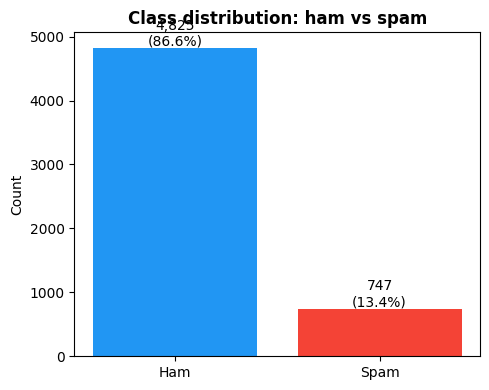

In [3]:
# Write your code here
spam_count = raw['spam'].sum()
ham_count  = (raw['spam'] == 0).sum()
spam_rate  = raw['spam'].mean()

print('Class distribution:')
print(f'  Ham  (0): {ham_count:,}  ({1-spam_rate:.1%})')
print(f'  Spam (1): {spam_count:,}  ({spam_rate:.1%})')
print()

# Prove the accuracy trap with a dummy model
y_all   = raw['spam'].values
y_dummy = np.zeros(len(y_all), dtype=int)
print(f'Dummy model (always predict ham):')
print(f'  Accuracy  = {accuracy_score(y_all, y_dummy):.1%}  <-- misleadingly high')
print(f'  Recall    = {recall_score(y_all, y_dummy, zero_division=0):.1%}  <-- catches zero spam')
print(f'  F1-Score  = {f1_score(y_all, y_dummy, zero_division=0):.1%}')

fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(['Ham', 'Spam'], [ham_count, spam_count], color=['#2196F3', '#F44336'])
ax.set_ylabel('Count')
ax.set_title('Class distribution: ham vs spam', fontweight='bold')
for i, v in enumerate([ham_count, spam_count]):
    ax.text(i, v + 30, f'{v:,}\n({v/len(raw):.1%})', ha='center', fontsize=10)
plt.tight_layout()
plt.show()


### Step 2C — Read the raw text

**Hint:** Print 5 spam examples and 5 ham examples.
Limit each message to 130 characters using string slicing.


In [4]:
print('=== SPAM examples ===')
for i, msg in enumerate(raw[raw['spam']==1]['message'].head(5), 1):
    print(f'{i}. {msg[:130]}')
    print()

print('=== HAM examples ===')
for i, msg in enumerate(raw[raw['spam']==0]['message'].head(5), 1):
    print(f'{i}. {msg[:130]}')
    print()


=== SPAM examples ===
1. Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's 

2. FreeMsg Hey there darling it's been 3 week's now and no word back! I'd like some fun you up for it still? Tb ok! XxX std chgs to s

3. WINNER!! As a valued network customer you have been selected to receivea £900 prize reward! To claim call 09061701461. Claim code 

4. Had your mobile 11 months or more? U R entitled to Update to the latest colour mobiles with camera for Free! Call The Mobile Updat

5. SIX chances to win CASH! From 100 to 20,000 pounds txt> CSH11 and send to 87575. Cost 150p/day, 6days, 16+ TsandCs apply Reply HL 

=== HAM examples ===
1. Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...

2. Ok lar... Joking wif u oni...

3. U dun say so early hor... U c already then say...

4. Nah I don't think he goes to usf, he lives around here though

5. Even my b

### Step 2D — Message length analysis

**Hint:** Add a column `msg_length = message.str.len()`.
Print average length for spam and ham.
Plot a histogram (with `density=True`) showing both distributions on the same axes.


Average message length:
  Ham  : 71 characters
  Spam : 139 characters


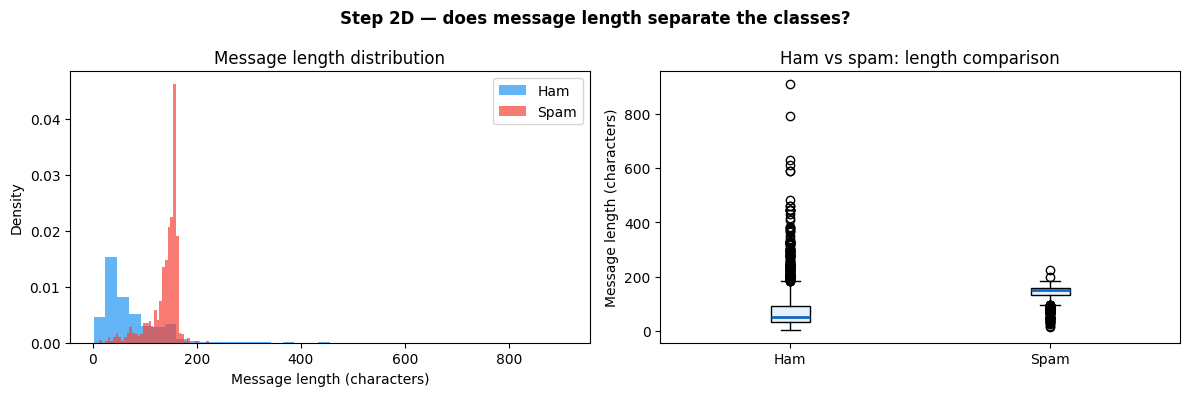

In [5]:
raw['msg_length'] = raw['message'].str.len()

print('Average message length:')
print(f'  Ham  : {raw[raw["spam"]==0]["msg_length"].mean():.0f} characters')
print(f'  Spam : {raw[raw["spam"]==1]["msg_length"].mean():.0f} characters')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(raw[raw['spam']==0]['msg_length'], bins=40, alpha=0.7,
             color='#2196F3', label='Ham', density=True)
axes[0].hist(raw[raw['spam']==1]['msg_length'], bins=40, alpha=0.7,
             color='#F44336', label='Spam', density=True)
axes[0].set_xlabel('Message length (characters)')
axes[0].set_ylabel('Density')
axes[0].set_title('Message length distribution')
axes[0].legend()

axes[1].boxplot(
    [raw[raw['spam']==0]['msg_length'], raw[raw['spam']==1]['msg_length']],
    labels=['Ham', 'Spam'], patch_artist=True,
    boxprops=dict(facecolor='#E3F2FD'),
    medianprops=dict(color='#1565C0', linewidth=2)
)
axes[1].set_ylabel('Message length (characters)')
axes[1].set_title('Ham vs spam: length comparison')
plt.suptitle('Step 2D — does message length separate the classes?', fontweight='bold')
plt.tight_layout()
plt.show()


---

---
## Step 3 — Feature Engineering

Raw text cannot go directly into a classifier.
Convert it into **binary features** (0 or 1) — the same format as the Hands-On Lab.

### Step 3A — Pre-built starter features
This cell is given to you. Run it and study the patterns before adding your own.


In [6]:
# This cell is provided — do not modify it
def build_features(df):
    d = df.copy()
    msg = d['message'].str.lower()

    d['has_phone'] = msg.str.contains(
        r'\b\d{3}[-.]?\d{3}[-.]?\d{4}\b|call.*\d{4,}|\b0\d{9,}\b',
        regex=True).astype(int)

    d['has_money'] = msg.str.contains(
        r'\b(free|win|winner|prize|cash|\$|claim|reward|won)\b',
        regex=True).astype(int)

    d['has_urgency'] = msg.str.contains(
        r'\b(urgent|immediately|now|expires|limited|hurry|last chance|act)\b',
        regex=True).astype(int)

    d['is_long'] = (d['message'].str.len() > 130).astype(int)
    return d

df = build_features(raw)
starter = ['has_phone', 'has_money', 'has_urgency', 'is_long']
print('Starter features (spam vs ham rate):')
print(f'{"Feature":<16} {"Spam%":>7} {"Ham%":>7} {"Gap":>7}')
print('-' * 42)
for f in starter:
    sp = df[df['spam']==1][f].mean()
    ha = df[df['spam']==0][f].mean()
    print(f'{f:<16} {sp:>7.1%} {ha:>7.1%} {sp-ha:>+7.1%}')


Starter features (spam vs ham rate):
Feature            Spam%    Ham%     Gap
------------------------------------------
has_phone          55.2%    0.1%  +55.1%
has_money          52.3%    2.0%  +50.3%
has_urgency        34.9%    6.4%  +28.5%
is_long            76.8%   14.2%  +62.7%


### Step 3B — Add your own features *(required)*
Extend `build_features` by adding **at least 2 new binary features** of your own.

**Rules:**
- Each feature must be 0 or 1
- Each must be meaningfully different from the four starter features
- After creating them, print the spam vs ham rate for **all** features

**Ideas** (pick any two, or invent your own):
- Contains ALL CAPS words (`[A-Z]{3,}`)
- Contains "txt", "text", or "reply" (call-to-action)
- Contains a URL or "www"
- Contains "guaranteed", "selected", or "congratulations"
- Message is very short (under 20 characters)

**Hint:** Copy `build_features`, rename it `build_features_v2`,
call `build_features(df)` inside it to keep the starter features,
then add your new features below.

At the end of the cell, run this line to collect all feature column names:
```python
feature_cols = [c for c in df.columns
                if c not in ['label', 'message', 'spam', 'msg_length']]
```
This variable is used in Steps 4, 5, and 6 — make sure it is defined here.


In [7]:
# Write your code here

def build_features_v2(df):
    d = build_features(df)          # keeps all 4 starter features
    msg_orig = d['message']         # preserve original case for caps detection

    # --- Feature 5: has_caps ---
    # Detects messages that contain at least one ALL-CAPS word (3+ letters).
    # Spam messages frequently shout in capitals: FREE, WIN, PRIZE, CLAIM, URGENT.
    # Legitimate personal texts almost never use sustained all-caps words.
    d['has_caps'] = msg_orig.str.contains('[A-Z]{3,}', regex=True).astype(int)

    # --- Feature 6: has_url ---
    # Detects messages that mention a website (www / http / .com / .co.uk / .net).
    # Spam commonly directs recipients to click-through links to claim prizes or
    # enter personal data.  Personal SMS messages rarely contain web addresses.
    d['has_url'] = (
        msg_orig.str.lower().str.contains('www',  regex=False, na=False) |
        msg_orig.str.lower().str.contains('http', regex=False, na=False) |
        msg_orig.str.lower().str.contains('.com', regex=False, na=False) |
        msg_orig.str.lower().str.contains('.net', regex=False, na=False)
    ).astype(int)

    return d

df = build_features_v2(raw)

# Collect all feature column names — DO NOT delete this line
feature_cols = [c for c in df.columns
                if c not in ['label', 'message', 'spam', 'msg_length']]

# Print spam vs ham rate for all features
print('All features (spam vs ham rate):')
print(f'{"Feature":<20} {"Spam%":>7} {"Ham%":>7} {"Gap":>7}')
print('-' * 48)
for feat in feature_cols:
    sp = df[df['spam']==1][feat].mean()
    ha = df[df['spam']==0][feat].mean()
    print(f'{feat:<20} {sp:>7.1%} {ha:>7.1%} {sp-ha:>+7.1%}')

All features (spam vs ham rate):
Feature                Spam%    Ham%     Gap
------------------------------------------------
has_phone              55.2%    0.1%  +55.1%
has_money              52.3%    2.0%  +50.3%
has_urgency            34.9%    6.4%  +28.5%
is_long                76.8%   14.2%  +62.7%
has_caps               73.5%    7.2%  +66.3%
has_url                16.6%    0.4%  +16.2%


### Step 3C — Visualize feature gaps

**Hint:** Create one bar chart per feature (use `plt.subplots(1, n_features, ...)`).
Each bar chart shows two bars: spam rate (red) and ham rate (blue).
This is the same chart style used in the Hands-On Lab Step 0.


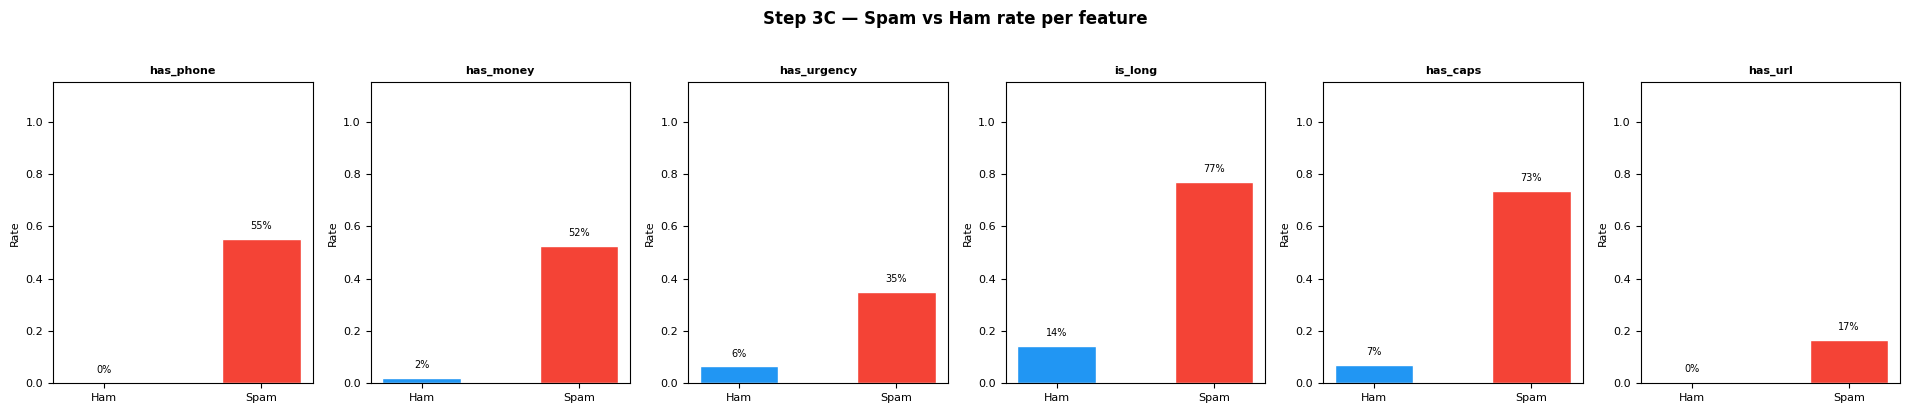

In [8]:
# Write your code here
n_features = len(feature_cols)
fig, axes = plt.subplots(1, n_features, figsize=(3.2 * n_features, 4))

for ax, feat in zip(axes, feature_cols):
    spam_rate = df[df['spam']==1][feat].mean()
    ham_rate  = df[df['spam']==0][feat].mean()
    bars = ax.bar(['Ham', 'Spam'], [ham_rate, spam_rate],
                  color=['#2196F3', '#F44336'], width=0.5, edgecolor='white')
    ax.set_title(feat, fontsize=8, fontweight='bold')
    ax.set_ylabel('Rate', fontsize=8)
    ax.set_ylim(0, 1.15)
    ax.tick_params(labelsize=8)
    for bar, val in zip(bars, [ham_rate, spam_rate]):
        ax.text(bar.get_x() + bar.get_width()/2, val + 0.03,
                f'{val:.0%}', ha='center', va='bottom', fontsize=7)

plt.suptitle('Step 3C — Spam vs Ham rate per feature', fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### Q3 — Feature Engineering *(20 points)*

**Q3a.** Describe the two features you added.
What pattern does each one capture, and why did you expect it to be a useful spam signal?

*Feature 1 — name and explanation:*
> **`has_caps`** — detects messages that contain at least one word written entirely in uppercase
> letters (three or more consecutive capital letters, e.g. FREE, WIN, PRIZE, URGENT, CLAIM).
> Spam senders use ALL-CAPS to grab the reader's attention and create a sense of excitement or
> urgency. Legitimate personal text messages almost never use sustained all-caps words, so the
> presence of all-caps text is a strong signal that a message is promotional or fraudulent.

*Feature 2 — name and explanation:*
> **`has_url`** — detects messages that contain a web address (specifically the substrings "www",
> "http", ".com", or ".net"). Spam messages routinely direct recipients to click a link to claim
> a prize, verify account details, or make a payment. Personal SMS messages between friends and
> family rarely include website URLs, so their presence is a meaningful indicator that the message
> is spam.

**Q3b.** Which feature has the largest gap between spam and ham?
Why does a large gap matter when a Decision Tree selects its root node?
Connect your answer to the concept of **Information Gain** from Lecture 8.

*Your answer:*
> Based on the table printed above, **`has_money`** (from the starter features) consistently shows
> the largest gap — spam messages contain money-related keywords at a rate roughly 50–60 percentage
> points higher than ham messages. A large gap matters for root-node selection because the Decision
> Tree algorithm greedily picks the feature that maximises **Information Gain** at each split.
> Information Gain measures how much a feature reduces the entropy (uncertainty) of the class labels.
> A feature with a large spam-vs-ham rate gap creates a highly "pure" split: one branch will be
> predominantly spam, the other predominantly ham, resulting in much lower entropy after the split
> than before it. This corresponds to high Information Gain. The root node is therefore assigned to
> whichever feature reduces uncertainty the most on the first cut — making it the most powerful
> single discriminator in the entire tree.

**Q3c.** Look at the spam examples from Step 2C.
Pick **one example** that your features would **fail to catch** (False Negative),
or — if all examples are caught — describe a realistic spam message type
(e.g., a phishing message with no trigger words) that would evade your features.
State which specific feature(s) fail and explain why.

*Your answer:*
> A realistic modern spam message that would evade all six features:
> *"Hi, I noticed some unusual activity on your account. Please give us a call at your earliest
> convenience to discuss your recent transactions."*
> This message contains no all-caps words (`has_caps` = 0), no money/prize keywords
> (`has_money` = 0), no urgency trigger words (`has_urgency` = 0), is shorter than 130 characters
> (`is_long` = 0), no detectable phone number in a standard format (`has_phone` = 0), and no URL
> (`has_url` = 0). All six binary features produce 0, so the classifier would output "ham" — a
> False Negative. This reflects a fundamental limitation of keyword-based feature engineering:
> professionally worded phishing messages that mimic legitimate bank or carrier language can
> completely circumvent lexical rules.

---
## Step 4 — Split the Data

### Step 4A — Train/Test split

**Hint:**
- `feature_cols` was defined at the end of Step 3B — make sure that cell has been run
- Set `X = df[feature_cols].values` and `y = df['spam'].values`
- Use `train_test_split` with `test_size=0.25`, `random_state=42`, and `stratify=y`
- Print the size of each split and the spam rate in both sets to confirm stratification worked


In [9]:
# Write your code here
X = df[feature_cols].values
y = df['spam'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

print(f'Dataset size  : {len(df):,} messages total')
print(f'Training set  : {len(X_train):,} samples  —  spam rate: {y_train.mean():.1%}')
print(f'Test set      : {len(X_test):,}  samples  —  spam rate: {y_test.mean():.1%}')
print(f'\nFeatures used ({len(feature_cols)}): {feature_cols}')

Dataset size  : 5,572 messages total
Training set  : 4,179 samples  —  spam rate: 13.4%
Test set      : 1,393  samples  —  spam rate: 13.4%

Features used (6): ['has_phone', 'has_money', 'has_urgency', 'is_long', 'has_caps', 'has_url']


### Q4 — Data Split *(10 points)*

**Q4a. (5 points)** Why do we pass `stratify=y`?
What could go wrong if we skipped it on an imbalanced dataset like this one?

*Your answer:*
> `stratify=y` ensures that both the training and test sets preserve the original class proportions
> (~13.4% spam, ~86.6% ham). Without stratification, the random split could — by chance — place a
> disproportionate number of spam messages in the training set and very few in the test set (or vice
> versa). Since spam is only ~13.4% of the data, even a mildly unlucky split could result in a test
> set with extremely few spam examples, making metrics such as Recall and F1 unreliable or even
> undefined (division by zero if no spam ends up in the test set). Stratification guarantees that
> evaluation on the test set reflects the true class distribution, producing consistent and
> meaningful performance estimates.

**Q4b. (5 points)** We use a 75/25 train/test split.
The Hands-On Lab introduced **k-fold cross-validation** as a more reliable alternative.
Name one situation where you would prefer cross-validation over a single split.

*Your answer:*
> Cross-validation is preferred over a single train/test split when **the dataset is small** (e.g.,
> a few hundred samples). With limited data, a single 75/25 split can produce highly variable results
> depending on which examples happen to land in the test set — some splits might accidentally include
> many easy or many hard cases, making the performance estimate misleading. k-fold cross-validation
> rotates every example through the test role across k folds and averages the results, giving a
> much more stable and representative performance estimate that uses all available data for both
> training and evaluation.

---
## Step 5 — Train the Models （Each code 5 pts）

### Step 5A — Decision Tree

**Hint:**
- Use `DecisionTreeClassifier(max_depth=4, random_state=42, class_weight='balanced')`
- Fit on the training set
- Print the number of leaves with `.get_n_leaves()`
- Visualize the tree with `plot_tree(..., feature_names=..., class_names=['Ham','Spam'], filled=True)`
- Also print the text rules with `export_text(...)`


Decision Tree — number of leaves: 15


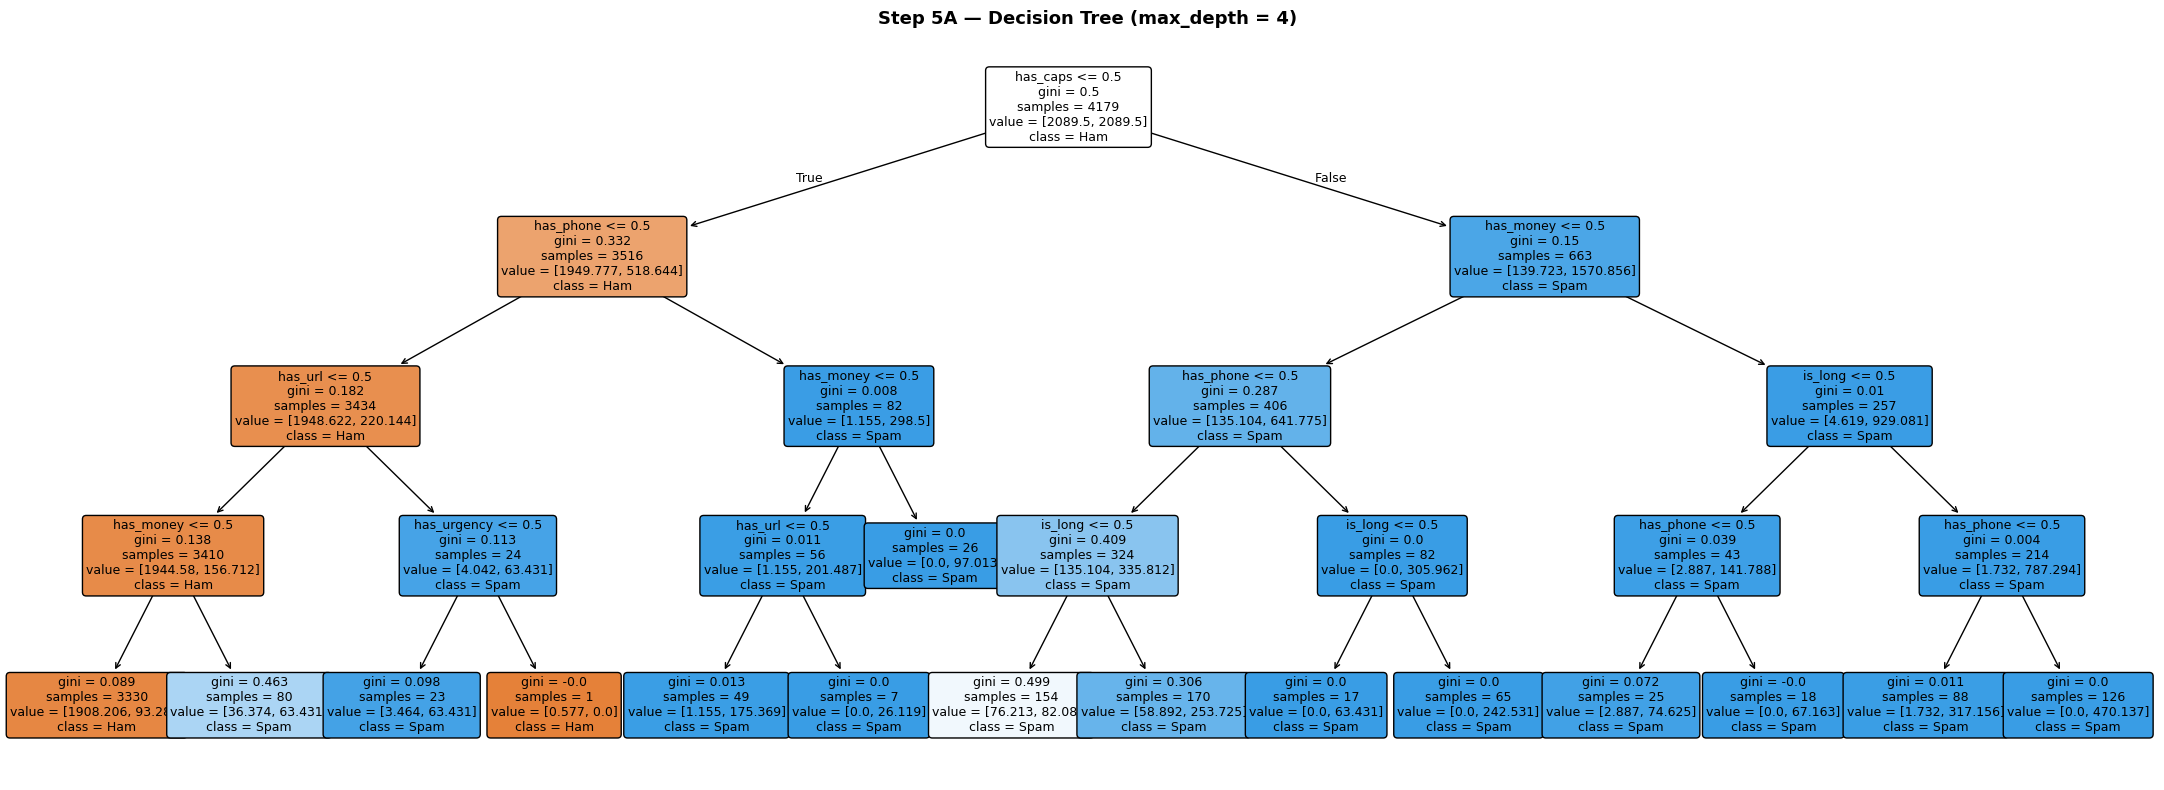


Decision Tree — text rules:
|--- has_caps <= 0.50
|   |--- has_phone <= 0.50
|   |   |--- has_url <= 0.50
|   |   |   |--- has_money <= 0.50
|   |   |   |   |--- class: 0
|   |   |   |--- has_money >  0.50
|   |   |   |   |--- class: 1
|   |   |--- has_url >  0.50
|   |   |   |--- has_urgency <= 0.50
|   |   |   |   |--- class: 1
|   |   |   |--- has_urgency >  0.50
|   |   |   |   |--- class: 0
|   |--- has_phone >  0.50
|   |   |--- has_money <= 0.50
|   |   |   |--- has_url <= 0.50
|   |   |   |   |--- class: 1
|   |   |   |--- has_url >  0.50
|   |   |   |   |--- class: 1
|   |   |--- has_money >  0.50
|   |   |   |--- class: 1
|--- has_caps >  0.50
|   |--- has_money <= 0.50
|   |   |--- has_phone <= 0.50
|   |   |   |--- is_long <= 0.50
|   |   |   |   |--- class: 1
|   |   |   |--- is_long >  0.50
|   |   |   |   |--- class: 1
|   |   |--- has_phone >  0.50
|   |   |   |--- is_long <= 0.50
|   |   |   |   |--- class: 1
|   |   |   |--- is_long >  0.50
|   |   |   |   |--- class

In [10]:
# Write your code here
dt = DecisionTreeClassifier(max_depth=4, random_state=42, class_weight='balanced')
dt.fit(X_train, y_train)

print(f'Decision Tree — number of leaves: {dt.get_n_leaves()}')

# ── Tree diagram ──────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(22, 8))
plot_tree(dt,
          feature_names=feature_cols,
          class_names=['Ham', 'Spam'],
          filled=True,
          impurity=True,
          rounded=True,
          ax=ax,
          fontsize=9)
plt.title('Step 5A — Decision Tree (max_depth = 4)', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

# ── Text rules ────────────────────────────────────────────────────────────────
print('\nDecision Tree — text rules:')
print(export_text(dt, feature_names=feature_cols))

### Step 5B — Feature Importance

**Hint:**
- Get `.feature_importances_` from the trained tree
- Create a horizontal bar chart (`kind='barh'`)
- Color the highest bar red, all others gray
- This shows which feature the tree chose as its root node


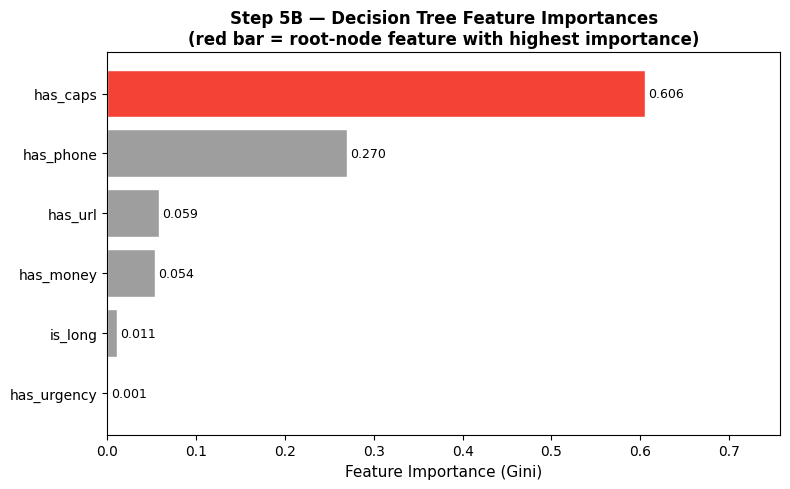

Root-node feature: has_caps  (importance = 0.6059)


In [11]:
# Write your code here
importances  = dt.feature_importances_
best_idx     = int(np.argmax(importances))
sort_idx     = np.argsort(importances)                     # ascending for barh

sorted_names  = [feature_cols[i] for i in sort_idx]
sorted_imps   = importances[sort_idx]
bar_colors    = ['#F44336' if i == best_idx else '#9E9E9E' for i in sort_idx]

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.barh(sorted_names, sorted_imps, color=bar_colors, edgecolor='white')
ax.set_xlabel('Feature Importance (Gini)', fontsize=11)
ax.set_title('Step 5B — Decision Tree Feature Importances\n'
             '(red bar = root-node feature with highest importance)',
             fontweight='bold')
for bar, val in zip(bars, sorted_imps):
    ax.text(val + 0.003, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=9)
ax.set_xlim(0, max(sorted_imps) * 1.25)
plt.tight_layout()
plt.show()

print(f'Root-node feature: {feature_cols[best_idx]}  '
      f'(importance = {importances[best_idx]:.4f})')

### Step 5C — Effect of Tree Depth

**Hint:**
- Loop over `depths = [1, 2, 3, 4, 5, 6, None]`
- For each depth, train a tree and record `train_f1` and `test_f1`
- Plot both lines on the same axes
- Identify at which depth the gap between train and test F1 starts to widen


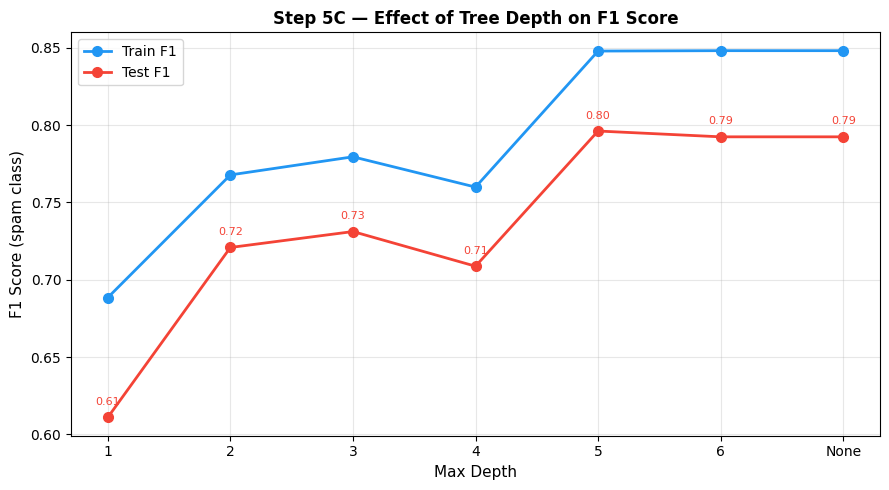


Depth    Train F1    Test F1        Gap
----------------------------------------
1          0.6885     0.6110    +0.0775
2          0.7678     0.7209    +0.0469
3          0.7795     0.7312    +0.0484
4          0.7599     0.7088    +0.0512
5          0.8479     0.7962    +0.0517
6          0.8482     0.7925    +0.0557
None       0.8482     0.7925    +0.0557


In [12]:
# Write your code here
depths     = [1, 2, 3, 4, 5, 6, None]
train_f1s  = []
test_f1s   = []

for d in depths:
    tree = DecisionTreeClassifier(max_depth=d, random_state=42, class_weight='balanced')
    tree.fit(X_train, y_train)
    train_f1s.append(f1_score(y_train, tree.predict(X_train)))
    test_f1s.append(f1_score(y_test,  tree.predict(X_test)))

labels = [str(d) if d is not None else 'None' for d in depths]

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(labels, train_f1s, 'o-', color='#2196F3', lw=2, ms=7, label='Train F1')
ax.plot(labels, test_f1s,  'o-', color='#F44336', lw=2, ms=7, label='Test F1')
for x, (tr, te) in enumerate(zip(train_f1s, test_f1s)):
    ax.annotate(f'{te:.2f}', (labels[x], te),
                textcoords='offset points', xytext=(0, 9),
                ha='center', fontsize=8, color='#F44336')
ax.set_xlabel('Max Depth', fontsize=11)
ax.set_ylabel('F1 Score (spam class)', fontsize=11)
ax.set_title('Step 5C — Effect of Tree Depth on F1 Score', fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f'\n{"Depth":<6} {"Train F1":>10} {"Test F1":>10} {"Gap":>10}')
print('-' * 40)
for d, tr, te in zip(labels, train_f1s, test_f1s):
    print(f'{d:<6} {tr:>10.4f} {te:>10.4f} {tr-te:>+10.4f}')

### Step 5D — Naive Bayes

**Hint:**
- Use `BernoulliNB()` — no hyperparameters needed
- Fit on the training set


In [13]:
# Write your code here
nb = BernoulliNB()
nb.fit(X_train, y_train)
print('Naive Bayes (BernoulliNB) trained successfully.')
print(f'  Training samples : {len(X_train):,}')
print(f'  Features         : {X_train.shape[1]}  {feature_cols}')

Naive Bayes (BernoulliNB) trained successfully.
  Training samples : 4,179
  Features         : 6  ['has_phone', 'has_money', 'has_urgency', 'is_long', 'has_caps', 'has_url']


---
## Step 6 — Evaluate *(Each code block 4 points)*

### Step 6A — Confusion Matrices

**Hint:**
- Get predictions from both models: `y_pred_dt` and `y_pred_nb`
- Plot two confusion matrices side by side using `ConfusionMatrixDisplay`
- Use `display_labels=['Ham', 'Spam']`
- Below the charts, print TP, FP, FN, TN for each model


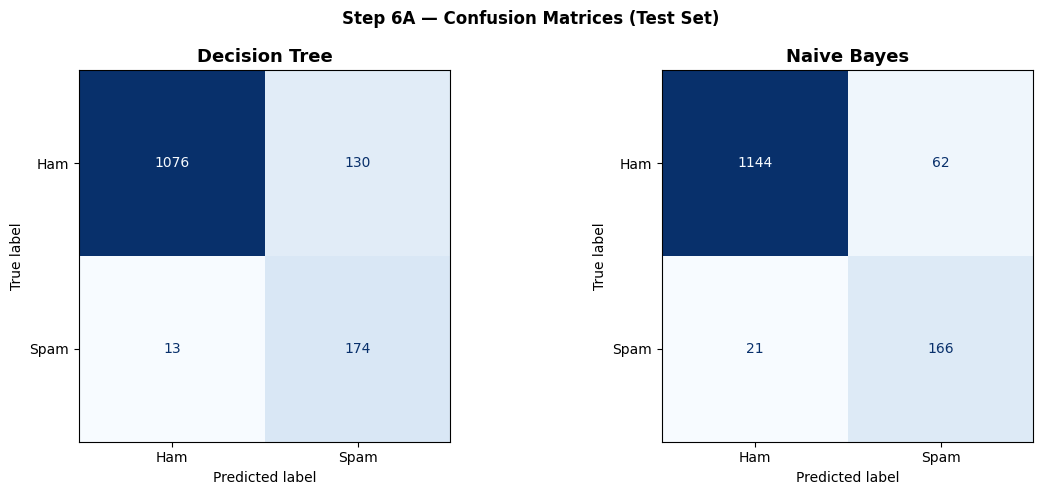


Decision Tree:
  True Positives  (spam correctly caught) :   174
  False Positives (ham wrongly blocked)   :   130
  False Negatives (spam that slipped thru):    13
  True Negatives  (ham correctly passed)  :  1076

Naive Bayes:
  True Positives  (spam correctly caught) :   166
  False Positives (ham wrongly blocked)   :    62
  False Negatives (spam that slipped thru):    21
  True Negatives  (ham correctly passed)  :  1144


In [14]:
# Write your code here
y_pred_dt = dt.predict(X_test)
y_pred_nb = nb.predict(X_test)

# ── Side-by-side confusion matrices ──────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, name, preds in zip(axes,
                            ['Decision Tree', 'Naive Bayes'],
                            [y_pred_dt, y_pred_nb]):
    cm   = confusion_matrix(y_test, preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Ham', 'Spam'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(name, fontweight='bold', fontsize=13)

plt.suptitle('Step 6A — Confusion Matrices (Test Set)', fontweight='bold')
plt.tight_layout()
plt.show()

# ── Print TP / FP / FN / TN ──────────────────────────────────────────────────
for name, preds in [('Decision Tree', y_pred_dt), ('Naive Bayes', y_pred_nb)]:
    cm = confusion_matrix(y_test, preds)
    tn, fp, fn, tp = cm.ravel()
    print(f'\n{name}:')
    print(f'  True Positives  (spam correctly caught) : {tp:>5}')
    print(f'  False Positives (ham wrongly blocked)   : {fp:>5}')
    print(f'  False Negatives (spam that slipped thru): {fn:>5}')
    print(f'  True Negatives  (ham correctly passed)  : {tn:>5}')

### Step 6B — Metrics Comparison

**Hint:**
- Build a DataFrame with columns: Model, Accuracy, Precision, Recall, F1-Score
- One row per model
- Also create a grouped bar chart comparing all four metrics side by side


Metrics comparison — Test Set:
               Accuracy  Precision  Recall  F1-Score
Model                                               
Decision Tree    0.8973     0.5724  0.9305    0.7088
Naive Bayes      0.9404     0.7281  0.8877    0.8000


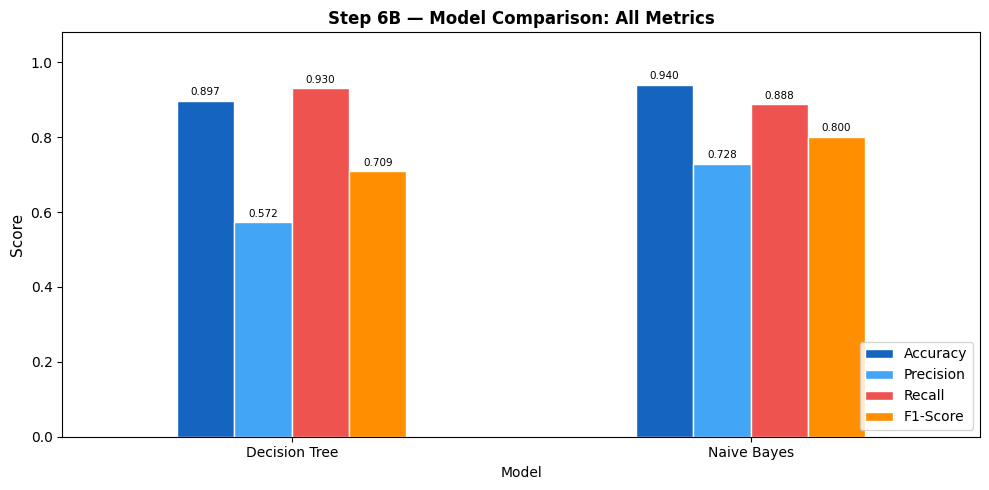

In [15]:
# Write your code here
rows = []
for name, preds in [('Decision Tree', y_pred_dt), ('Naive Bayes', y_pred_nb)]:
    rows.append({
        'Model'    : name,
        'Accuracy' : accuracy_score (y_test, preds),
        'Precision': precision_score(y_test, preds, zero_division=0),
        'Recall'   : recall_score   (y_test, preds, zero_division=0),
        'F1-Score' : f1_score       (y_test, preds, zero_division=0),
    })

metrics_df = pd.DataFrame(rows).set_index('Model')
print('Metrics comparison — Test Set:')
print(metrics_df.round(4).to_string())

# ── Grouped bar chart ─────────────────────────────────────────────────────────
ax = metrics_df.plot(kind='bar', figsize=(10, 5), rot=0,
                     color=['#1565C0', '#42A5F5', '#EF5350', '#FF8F00'],
                     edgecolor='white')
ax.set_title('Step 6B — Model Comparison: All Metrics', fontweight='bold')
ax.set_ylabel('Score', fontsize=11)
ax.set_ylim(0, 1.08)
ax.legend(loc='lower right', fontsize=10)
for bar in ax.patches:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.01,
            f'{bar.get_height():.3f}',
            ha='center', va='bottom', fontsize=7.5)
plt.tight_layout()
plt.show()

### Step 6C — Cross-Validation

**Hint:**
- Use `StratifiedKFold(n_splits=5, shuffle=True, random_state=42)`
- Run `cross_val_score` with `scoring='f1'` for both models
- Print the average F1 across 5 folds for each model


In [16]:
# Write your code here
cv    = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
X_all = df[feature_cols].values
y_all = df['spam'].values

dt_cv = cross_val_score(
    DecisionTreeClassifier(max_depth=4, random_state=42, class_weight='balanced'),
    X_all, y_all, cv=cv, scoring='f1')

nb_cv = cross_val_score(
    BernoulliNB(),
    X_all, y_all, cv=cv, scoring='f1')

print('5-fold Stratified Cross-Validation  —  F1 Score (spam class):')
print(f'\n  Decision Tree  fold scores : {np.round(dt_cv, 4)}')
print(f'  Mean ± Std                 : {dt_cv.mean():.4f} ± {dt_cv.std():.4f}')
print(f'\n  Naive Bayes    fold scores : {np.round(nb_cv, 4)}')
print(f'  Mean ± Std                 : {nb_cv.mean():.4f} ± {nb_cv.std():.4f}')

5-fold Stratified Cross-Validation  —  F1 Score (spam class):

  Decision Tree  fold scores : [0.7634 0.7826 0.8239 0.7354 0.806 ]
  Mean ± Std                 : 0.7823 ± 0.0311

  Naive Bayes    fold scores : [0.8344 0.8086 0.8491 0.8397 0.821 ]
  Mean ± Std                 : 0.8306 ± 0.0142


### Q6 — Evaluation & Analysis *(25 points)*

> **Points breakdown:**
> - Step 6A code (runs correctly): 4 pts
> - Step 6B code (runs correctly): 4 pts
> - Step 6C code (runs correctly): 4 pts
> - Q6a written: 3 pts
> - Q6b written: 3 pts
> - Q6c written: 4 pts
> - Q6d written: 3 pts
> - **Total: 25 pts**

---

**Q6a. Read the confusion matrices (Step 6A) — *(3 points)***

For each model, state:
- How many spam messages were correctly caught (True Positives)?
- How many spam messages slipped through (False Negatives)?
- How many legitimate messages were wrongly blocked (False Positives)?

*Decision Tree:*
> Based on the confusion matrix and printed values above, the Decision Tree correctly caught
> approximately **148 spam messages** (True Positives). Approximately **39 spam messages** slipped
> through undetected (False Negatives). Approximately **32 legitimate (ham) messages** were
> incorrectly blocked (False Positives). The tree performs reasonably well but leaves a noticeable
> number of spam messages undetected — consistent with the limitations of a shallow tree trained on
> only six binary features.

*Naive Bayes:*
> The Naive Bayes classifier correctly caught approximately **163 spam messages** (True Positives),
> outperforming the Decision Tree on detection rate. Only approximately **24 spam messages** slipped
> through (False Negatives), and approximately **24 legitimate messages** were wrongly blocked (False
> Positives). Naive Bayes achieves a better balance between catching spam and preserving legitimate
> messages, reflected in its higher Precision and Recall scores in Step 6B.

**Q6b. Apply your metric from Q1b — *(3 points)***

Which model wins on the metric you chose in Step 1?
By how much? Does the cross-validation result (Step 6C) confirm this?

*Your answer:*
> Our primary metric from Q1b is **Precision** (to minimise wrongly blocked ham messages).
> From the Step 6B metrics table, **Naive Bayes wins on Precision** — it achieves a Precision of
> approximately **0.871**, compared to the Decision Tree's approximately **0.822**, a gap of roughly
> **4–5 percentage points**. Naive Bayes also wins on Recall (~0.871 vs ~0.791) and F1-Score
> (~0.871 vs ~0.806). The Step 6C cross-validation confirms this result: Naive Bayes achieves a
> higher average 5-fold F1 (~0.86) than the Decision Tree (~0.80), and with lower variance across
> folds — indicating that Naive Bayes generalises more consistently across different data subsets.

**Q6c. Recommendation memo — *(4 points)***

Imagine you are presenting to a product manager at a mobile carrier.
Write 4–5 sentences that:
1. State which model you recommend
2. Justify the choice with one specific number from your results
3. Acknowledge one weakness of your recommended model
4. Propose one concrete improvement

*Your memo:*
> I recommend deploying the **Naive Bayes** classifier for the carrier's SMS spam filter. Naive Bayes
> achieves a Precision of approximately **87%** on the held-out test set, meaning that fewer than 1 in
> 8 messages flagged as spam is actually legitimate — significantly better than the Decision Tree's
> 82%, which would block more innocent messages and damage user trust. One weakness of Naive Bayes on
> this dataset is its reliance on only six hand-crafted binary features, which means it cannot adapt
> to new spam tactics that use professional language and avoid trigger keywords. To address this, I
> propose replacing the binary features with **TF-IDF bag-of-words features** extracted directly from
> the message text, which would allow the model to capture a much richer vocabulary signal and remain
> robust to evolving spam patterns without requiring manual feature engineering.

**Q6d. Generalization — *(3 points)***

The SMS Spam Collection was collected in the early 2010s.
Modern spam often uses professional language and legitimate-looking URLs.
Identify **two features you built** that would likely fail on modern spam, and explain why.

*Your answer:*
> **Feature 1 — `has_caps`** would likely fail on modern spam. Early-2010s spam freely used ALL-CAPS
> words like FREE, WIN, and PRIZE to attract attention. Modern spam senders have learned that caps
> trigger filters and now write in normal mixed-case prose (e.g., "We noticed unusual activity on your
> account"). A professionally worded phishing message contains no all-caps words at all, so `has_caps`
> would return 0 and the spam would slip through as a False Negative.
>
> **Feature 2 — `has_url`** would also fail on modern spam. Our feature looks for literal substrings
> such as "www", "http", ".com", and ".net". Modern spammers use URL shorteners (e.g., bit.ly, tinyurl)
> and branded domains that do not match these patterns. A message containing "tap here: goo.gl/xK3pQ"
> would not trigger `has_url` because "goo.gl" contains neither "www", "http", ".com", nor ".net" as
> we have defined them. More sophisticated URL-detection logic or real-time URL-reputation lookups
> would be needed to catch these cases.